In [9]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

In [10]:
df = pd.read_csv('reviews.csv')

df.head()

,review_text,rating,sentiment
0,This product is absolutely amazing! Best purch...,5,1
1,Terrible quality. Broke after one week. Total ...,1,0
2,Pretty good for the price. Would recommend to ...,4,1
3,Not bad but expected better quality for this p...,3,1
4,Excellent! Exceeded all my expectations. Love it!,5,1


In [11]:
cleaned_texts = []

for text in df['review_text']:
    text = str(text).lower()
    
    words = text.split()
    
    filtered_words = [word for word in words if word not in stop_words]
    
    cleaned_texts.append(" ".join(filtered_words))

df['cleaned_review'] = cleaned_texts

df[['review_text', 'cleaned_review']].head()

,review_text,cleaned_review
0,This product is absolutely amazing! Best purch...,product absolutely amazing! best purchase ever.
1,Terrible quality. Broke after one week. Total ...,terrible quality. broke one week. total waste ...
2,Pretty good for the price. Would recommend to ...,pretty good price. would recommend friends.
3,Not bad but expected better quality for this p...,bad expected better quality price.
4,Excellent! Exceeded all my expectations. Love it!,excellent! exceeded expectations. love it!


In [12]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_review'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 81.82%


In [14]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_preds)

print(f"Naive Bayes Accuracy: {nb_accuracy * 100:.2f}%")

Naive Bayes Accuracy: 90.91%


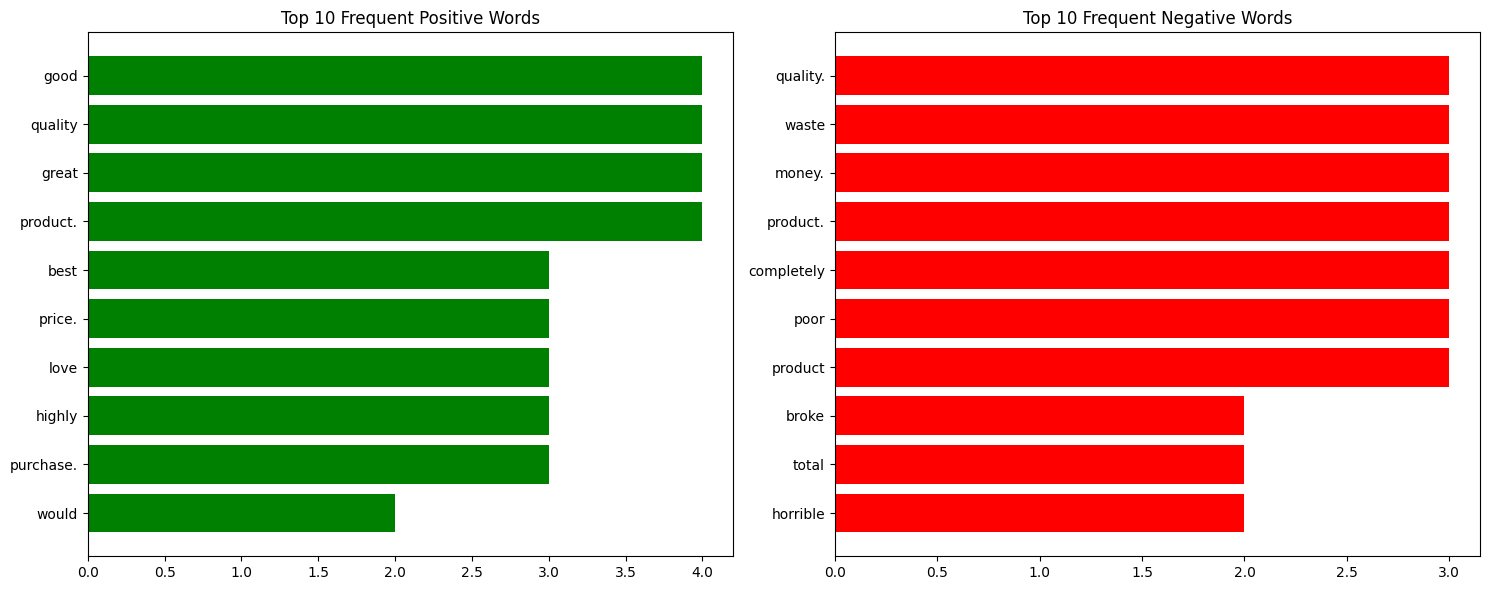

In [15]:
import matplotlib.pyplot as plt
from collections import Counter

positive_reviews = df[df['sentiment'] == 1]['cleaned_review']
negative_reviews = df[df['sentiment'] == 0]['cleaned_review']

positive_words = " ".join(positive_reviews).split()
negative_words = " ".join(negative_reviews).split()

top_positive = Counter(positive_words).most_common(10)
top_negative = Counter(negative_words).most_common(10)

pos_words, pos_counts = zip(*top_positive)
neg_words, neg_counts = zip(*top_negative)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(pos_words, pos_counts, color='green')
axes[0].set_title('Top 10 Frequent Positive Words')
axes[0].invert_yaxis() 

axes[1].barh(neg_words, neg_counts, color='red')
axes[1].set_title('Top 10 Frequent Negative Words')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()